# DEC clustering analysis

Same deduplication procedure as `clustering_analysis_11_mice_before_dec.ipynb` (neurons that are
the same physical cell imaged across adjacent z-planes are merged based on 3D position + response
correlation), but instead of running KMeans/GMM live on readout embeddings, cluster labels are
loaded from the `predicted` field already saved in each DEC/KL training run's `output_dict.pkl`
under `sensorium/training/correct_runs/` (grid of seed x cluster_number x base_multiplier).

In [1]:
import os
import pickle
from collections import Counter
from itertools import combinations

import numpy as np
import torch
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.metrics import adjusted_rand_score

In [2]:
# ---- sweep config (ARI-vs-cluster-count analysis) ----
SEEDS = [42, 83, 101, 311, 569]
CLUSTER_NUMBERS = [5, 10, 15, 20, 25, 30, 40, 50, 60]
BASE_MULTIPLIERS = ['1e4', '4e3']
RUNS_DIR = os.path.join('..', 'training', 'correct_runs')

# ---- t-SNE config (single representative run) ----
TSNE_SEED = 42
TSNE_CLUSTER_NUMBER = 30
TSNE_BASE_MULTIPLIER = '1e4'

DATA_HASH = '94c6ff995dac583098847cfecd43e7b6'


def run_dir_for(seed, cluster_number, base_multiplier):
    return os.path.join(RUNS_DIR, f'corr_kl_11mice_seed{seed}_cl{cluster_number}_bm{base_multiplier}')

## 1. Discover session order and per-session neuron counts

`predicted` in `output_dict.pkl` is a flat, per-neuron array built by concatenating each
session's soft-assignment in the order `model.readout.items()` iterates (see
`sensorium/sensorium/training/trainers.py`). That order matches the order sessions appear as
`readout.<session_id>._features` keys in `model_weights.pth` (both are the same insertion-ordered
`ModuleDict`), so we can recover it directly from any run's checkpoint without rebuilding the
model or dataloaders. This is computed once and reused for every run, since all 90 runs share
the same dataset/model architecture (only seed / cluster_number / base_multiplier differ).

In [3]:
def get_session_order_and_sizes(run_dir):
    state_dict = torch.load(os.path.join(run_dir, 'model_weights.pth'), map_location='cpu')
    session_ids, sizes = [], []
    for key, value in state_dict.items():
        if key.startswith('readout.') and key.endswith('._features'):
            session_ids.append(key[len('readout.'):-len('._features')])
            sizes.append(value.shape[0])
    return session_ids, sizes


animals, session_sizes = get_session_order_and_sizes(run_dir_for(101, 10, '1e4'))
session_offsets = np.cumsum([0] + session_sizes)
n_neurons_total = int(session_offsets[-1])
print(f'{len(animals)} sessions, {n_neurons_total} neurons total')

# sanity check: a different (seed, cluster_number, base_multiplier) run has the identical
# session order/sizes, since only the trained weights differ, not the architecture
other_animals, other_sizes = get_session_order_and_sizes(run_dir_for(42, 30, '4e3'))
assert animals == other_animals and session_sizes == other_sizes

11 sessions, 77709 neurons total


## 2. Per-animal deduplication

Ported as-is from `clustering_analysis_11_mice_before_dec.ipynb` (`dedup_animal`,
`RADIUS = 4`, `CORR_THRESHOLD = 0.8`): for each neuron, walk outward through z-planes in both
directions, picking the laterally-nearest neuron at each step, stopping the chain once lateral
drift exceeds `RADIUS` or response correlation drops to `<= CORR_THRESHOLD`; neurons linked this
way are merged transitively (union-find) into duplicate groups. This depends only on the
dataset (coordinates + responses), not on any trained model, so it is computed once per animal
and reused for every (seed, cluster_number, base_multiplier) combination below.

In [4]:
# same dataset paths/hash sensorium/training/train.py uses to build these runs' dataloaders
BASE_CANDIDATES = [
    ('/srv/user/polina/sensorium/sensorium/notebooks/data', '-GrayImageNet-'),
    ('/user/turishcheva/more_data_like_sensorium_2022', '-'),
]


def resolve_session_dir(session_id):
    for base, link in BASE_CANDIDATES:
        candidate = os.path.join(base, f'static{session_id}{link}{DATA_HASH}')
        if os.path.isdir(candidate):
            return candidate
    raise FileNotFoundError(f'Could not find a data directory for session {session_id}')


def load_coords(session_id):
    return np.load(os.path.join(
        resolve_session_dir(session_id), 'meta', 'neurons', 'cell_motor_coordinates.npy'
    ))


def load_responses(session_id):
    path = os.path.join(resolve_session_dir(session_id), 'data', 'responses')
    n = len(os.listdir(path))
    return np.vstack([np.load(os.path.join(path, f'{j}.npy')) for j in range(n)]).T  # (neurons, images)

In [5]:
RADIUS = 4
CORR_THRESHOLD = 0.8


def dedup_animal(coords_a, responses_a):
    n = len(coords_a)
    def corr(x, y):
        x = x - x.mean(); y = y - y.mean()
        return np.dot(x, y) / np.sqrt(np.dot(x, x) * np.dot(y, y))

    def walk_z(planes, z_order, target_resp, prev_xy):
        copies = []
        for z in z_order:
            gidx, x, y = min(planes[z], key=lambda t: abs(t[1]-prev_xy[0]) + abs(t[2]-prev_xy[1]))
            if abs(x-prev_xy[0]) > RADIUS or abs(y-prev_xy[1]) > RADIUS:
                break
            if corr(target_resp, responses_a[gidx]) <= CORR_THRESHOLD:
                break
            copies.append(gidx)
            prev_xy = (x, y)
        return copies

    planes = {}
    for g in range(n):
        x, y, z = coords_a[g]
        planes.setdefault(z, []).append((g, x, y))
    sorted_z = sorted(planes)

    copy_dict = {}
    for g in range(n):
        x, y, z = coords_a[g]
        target = responses_a[g]
        up   = [zz for zz in sorted_z if zz > z]
        down = [zz for zz in sorted_z if zz < z][::-1]
        copies = walk_z(planes, up, target, (x, y)) + walk_z(planes, down, target, (x, y))
        if copies:
            copy_dict[g] = copies

    parent = {}
    def find(x):
        parent.setdefault(x, x)
        while parent[x] != x:
            parent[x] = parent[parent[x]]; x = parent[x]
        return x
    def union(a, b):
        parent[find(a)] = find(b)
    for neuron, copies in copy_dict.items():
        for c in copies:
            union(neuron, c)

    groups = {}
    for node in parent:
        groups.setdefault(find(node), set()).add(node)
    unique_groups = list(groups.values())
    grouped = set().union(*unique_groups) if unique_groups else set()
    individual_neurons = sorted(set(range(n)) - grouped)
    return unique_groups, individual_neurons

In [6]:
coords_per_animal = {}
unique_groups_per_animal = {}
individual_neurons_per_animal = {}

for a, n_neurons in tqdm(list(zip(animals, session_sizes))):
    coords_a = load_coords(a)
    responses_a = load_responses(a)
    assert len(coords_a) == len(responses_a) == n_neurons, (
        f'{a}: coords/responses neuron count does not match checkpoint ({len(coords_a)} vs {n_neurons})'
    )
    unique_groups, individual_neurons = dedup_animal(coords_a, responses_a)
    coords_per_animal[a] = coords_a
    unique_groups_per_animal[a] = unique_groups
    individual_neurons_per_animal[a] = individual_neurons
    print(f'{a}: {n_neurons} neurons -> {len(individual_neurons)} individual + {len(unique_groups)} duplicate groups')

  9%|▉         | 1/11 [00:07<01:15,  7.53s/it]

23343-5-17: 7334 neurons -> 1389 individual + 1796 duplicate groups


 18%|█▊        | 2/11 [00:15<01:12,  8.05s/it]

23964-4-22: 8098 neurons -> 1768 individual + 2098 duplicate groups


 27%|██▋       | 3/11 [00:24<01:07,  8.38s/it]

...

22564-2-12: 8115 neurons -> 8033 individual + 40 duplicate groups


 91%|█████████ | 10/11 [01:10<00:06,  6.24s/it]

22620-4-15: 7957 neurons -> 1437 individual + 2009 duplicate groups


100%|██████████| 11/11 [01:15<00:00,  6.90s/it]

23555-5-12: 6559 neurons -> 1734 individual + 1444 duplicate groups


## 3. Loading DEC cluster labels from `output_dict.pkl`

`load_predicted` is robust to the known bug where 18/90 runs have their `output_dict.pkl`
misplaced directly under `correct_runs/` (e.g. `correct_runs/<run_name>output_dict.pkl`) instead
of inside their run directory (a since-fixed path-join bug in `train.py`) — it transparently
falls back to that stray-file location rather than requiring any files to be moved.

When a dedup group's members don't all share the same predicted label, the group's label is
resolved by **majority vote**.

In [7]:
def load_predicted(run_dir):
    primary = os.path.join(run_dir, 'output_dict.pkl')
    if os.path.exists(primary):
        pkl_path = primary
    else:
        parent, name = os.path.split(run_dir.rstrip('/'))
        pkl_path = os.path.join(parent, f'{name}output_dict.pkl')
    with open(pkl_path, 'rb') as f:
        output_dict = pickle.load(f)
    predicted = output_dict['predicted']
    if torch.is_tensor(predicted):
        predicted = predicted.cpu().numpy()
    return np.asarray(predicted)


def reduce_labels(predicted, unique_groups, individual_neurons):
    individual_labels = predicted[individual_neurons]
    if unique_groups:
        group_labels = np.array([
            Counter(predicted[list(g)].tolist()).most_common(1)[0][0]
            for g in unique_groups
        ])
    else:
        group_labels = np.empty((0,), dtype=predicted.dtype)
    return np.concatenate([individual_labels, group_labels])


def load_reduced_labels_for_run(run_dir):
    predicted = load_predicted(run_dir)
    assert len(predicted) == n_neurons_total
    reduced = []
    for a, lo, hi in zip(animals, session_offsets[:-1], session_offsets[1:]):
        reduced.append(reduce_labels(
            predicted[lo:hi], unique_groups_per_animal[a], individual_neurons_per_animal[a]
        ))
    return np.concatenate(reduced)

## 4. ARI consistency across seeds vs. cluster count

For each `(cluster_number, base_multiplier)`, deduped cluster labels are loaded for all 5 seeds
and compared pairwise via Adjusted Rand Index (ARI) — the direct analogue of the old notebook's
model-seed ARI curve, except the labels come from the saved DEC training run instead of a fresh
KMeans/GMM fit.

In [8]:
ari_mean = {bm: {} for bm in BASE_MULTIPLIERS}
ari_std = {bm: {} for bm in BASE_MULTIPLIERS}

for bm in BASE_MULTIPLIERS:
    for cl in tqdm(CLUSTER_NUMBERS, desc=f'base_multiplier={bm}'):
        labels_per_seed = [
            load_reduced_labels_for_run(run_dir_for(seed, cl, bm))
            for seed in SEEDS
        ]
        scores = [
            adjusted_rand_score(labels_per_seed[i], labels_per_seed[j])
            for i, j in combinations(range(len(SEEDS)), 2)
        ]
        ari_mean[bm][cl] = np.mean(scores)
        ari_std[bm][cl] = np.std(scores, ddof=1)

base_multiplier=4e3: 100%|██████████| 9/9 [00:03<00:00,  2.48it/s]


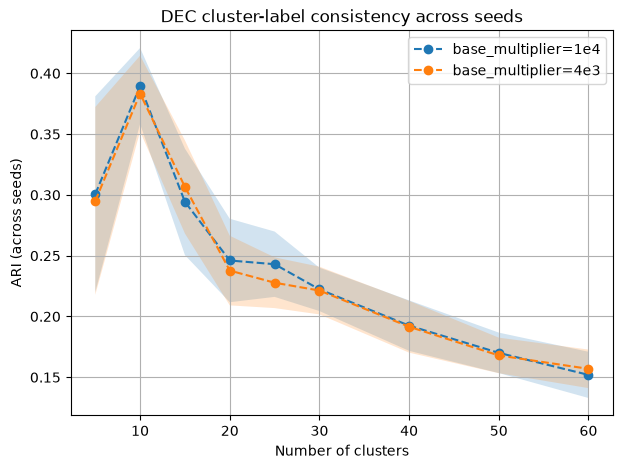

In [9]:
plt.figure(figsize=(7, 5))
for bm in BASE_MULTIPLIERS:
    means = np.array([ari_mean[bm][cl] for cl in CLUSTER_NUMBERS])
    stds = np.array([ari_std[bm][cl] for cl in CLUSTER_NUMBERS])
    plt.plot(CLUSTER_NUMBERS, means, ls='--', marker='o', label=f'base_multiplier={bm}')
    plt.fill_between(CLUSTER_NUMBERS, means - stds, means + stds, alpha=0.2)
plt.grid()
plt.xlabel('Number of clusters')
plt.ylabel('ARI (across seeds)')
plt.legend()
plt.title('DEC cluster-label consistency across seeds')
plt.show()

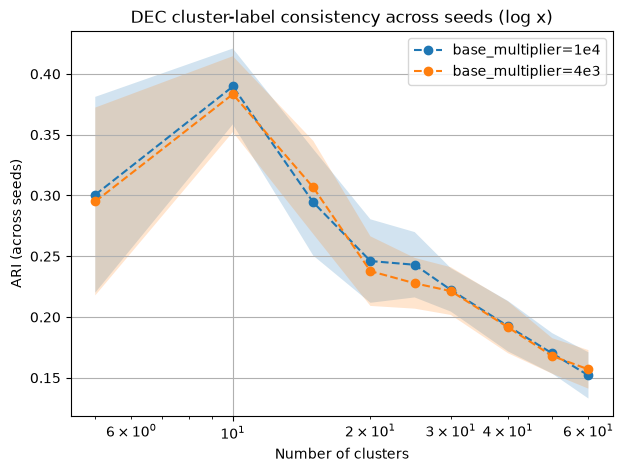

In [10]:
plt.figure(figsize=(7, 5))
for bm in BASE_MULTIPLIERS:
    means = np.array([ari_mean[bm][cl] for cl in CLUSTER_NUMBERS])
    stds = np.array([ari_std[bm][cl] for cl in CLUSTER_NUMBERS])
    plt.plot(CLUSTER_NUMBERS, means, ls='--', marker='o', label=f'base_multiplier={bm}')
    plt.fill_between(CLUSTER_NUMBERS, means - stds, means + stds, alpha=0.2)
plt.grid()
plt.xscale('log')
plt.xlabel('Number of clusters')
plt.ylabel('ARI (across seeds)')
plt.legend()
plt.title('DEC cluster-label consistency across seeds (log x)')
plt.show()

## 5. t-SNE visualization for one representative run

Uses the readout embeddings (whitened the same way as the old notebook) and the DEC cluster
labels from a single selected run (`TSNE_SEED` / `TSNE_CLUSTER_NUMBER` / `TSNE_BASE_MULTIPLIER`
above), deduped the same way as the ARI analysis — except embeddings are reduced per group by
**mean** (not majority vote, since they're continuous).

In [11]:
def whiten_readouts(cov_ema, readouts, eps=1e-5):
    eye = torch.eye(cov_ema.shape[0], dtype=cov_ema.dtype, device='cpu')
    L = torch.linalg.cholesky(cov_ema + eps * eye)
    whitened_readouts = L.T @ readouts.T
    return whitened_readouts.T


tsne_run_dir = run_dir_for(TSNE_SEED, TSNE_CLUSTER_NUMBER, TSNE_BASE_MULTIPLIER)
tsne_state_dict = torch.load(os.path.join(tsne_run_dir, 'model_weights.pth'), map_location='cpu')
mu_ema, cov_ema = tsne_state_dict['whitener.mu_ema'], tsne_state_dict['whitener.cov_ema']

whitened_per_animal = {
    a: whiten_readouts(cov_ema, tsne_state_dict[f'readout.{a}._features'].squeeze()).numpy()
    for a in animals
}
tsne_predicted = load_predicted(tsne_run_dir)

In [12]:
per_animal_embeddings = {}
per_animal_positions = {}
per_animal_labels = {}

for a, lo, hi in zip(animals, session_offsets[:-1], session_offsets[1:]):
    unique_groups = unique_groups_per_animal[a]
    individual_neurons = individual_neurons_per_animal[a]
    coords_a = coords_per_animal[a]
    wh = whitened_per_animal[a]

    grp_emb = (np.stack([wh[list(g)].mean(0) for g in unique_groups])
               if unique_groups else np.empty((0, wh.shape[1])))
    per_animal_embeddings[a] = np.vstack([wh[individual_neurons], grp_emb])

    grp_pos = (np.stack([coords_a[list(g)].mean(0) for g in unique_groups])
               if unique_groups else np.empty((0, 3)))
    per_animal_positions[a] = np.vstack([coords_a[individual_neurons], grp_pos])

    per_animal_labels[a] = reduce_labels(tsne_predicted[lo:hi], unique_groups, individual_neurons)

all_together, all_positions, all_labels, mice_ids = [], [], [], []
for idx, a in enumerate(animals):
    all_together.append(per_animal_embeddings[a])
    all_positions.append(per_animal_positions[a])
    all_labels.append(per_animal_labels[a])
    mice_ids += [idx] * per_animal_embeddings[a].shape[0]

all_together_stacked = np.vstack(all_together)
all_positions_stacked = np.vstack(all_positions)
all_labels_stacked = np.concatenate(all_labels)
mice_ids = np.array(mice_ids)
all_together_stacked.shape

(40722, 96)

In [13]:
X_embedded = TSNE(n_components=2).fit_transform(all_together_stacked)

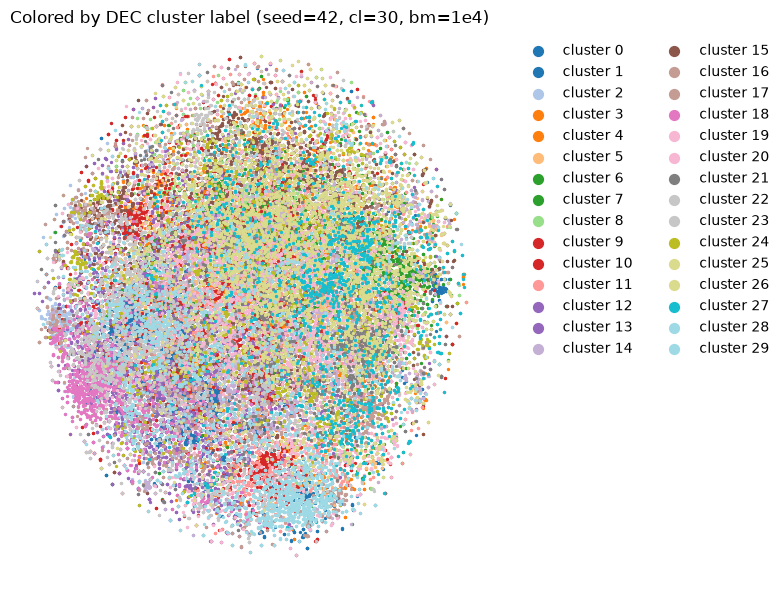

In [14]:
plt.figure(figsize=(8, 6))
unique_labels = np.unique(all_labels_stacked)
colors = plt.cm.tab20(np.linspace(0, 1, max(len(unique_labels), 2)))
for cluster_id, color in zip(unique_labels, colors):
    mask = all_labels_stacked == cluster_id
    plt.scatter(X_embedded[mask, 0], X_embedded[mask, 1], s=2, color=color, label=f'cluster {cluster_id}')
plt.xticks([]); plt.yticks([])
for spine in plt.gca().spines.values():
    spine.set_visible(False)
plt.legend(frameon=False, bbox_to_anchor=(1.05, 1), loc='upper left', markerscale=5, ncol=2)
plt.title(f'Colored by DEC cluster label (seed={TSNE_SEED}, cl={TSNE_CLUSTER_NUMBER}, bm={TSNE_BASE_MULTIPLIER})')
plt.tight_layout()
plt.show()

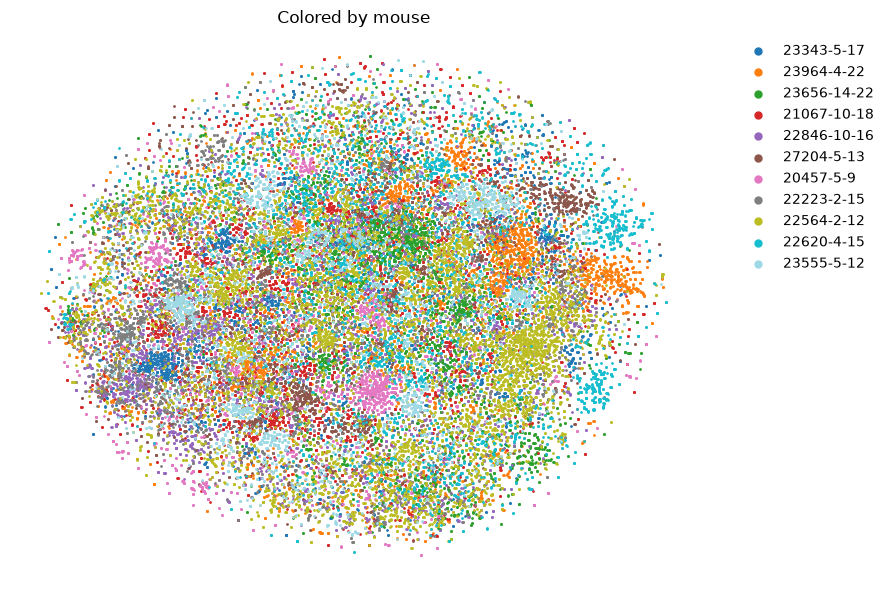

In [15]:
plt.figure(figsize=(9, 6))
colors = plt.cm.tab20(np.linspace(0, 1, len(np.unique(mice_ids))))
for mouse_id, color in zip(np.unique(mice_ids), colors):
    mask = mice_ids == mouse_id
    plt.scatter(X_embedded[mask, 0], X_embedded[mask, 1], s=1, color=color, label=animals[mouse_id])
plt.xticks([]); plt.yticks([])
for spine in plt.gca().spines.values():
    spine.set_visible(False)
plt.legend(frameon=False, bbox_to_anchor=(1.05, 1), loc='upper left', markerscale=5)
plt.title('Colored by mouse')
plt.tight_layout()
plt.show()

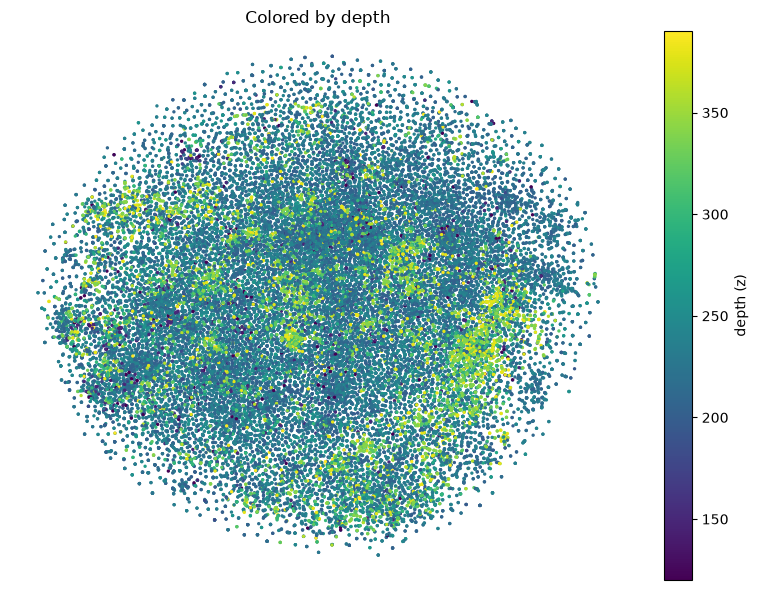

: 

In [16]:
plt.figure(figsize=(8, 6))
z = all_positions_stacked[:, 2]
sc = plt.scatter(X_embedded[:, 0], X_embedded[:, 1], s=2, c=z, cmap='viridis')
plt.xticks([]); plt.yticks([])
for spine in plt.gca().spines.values():
    spine.set_visible(False)
plt.colorbar(sc, label='depth (z)')
plt.title('Colored by depth')
plt.tight_layout()
plt.show()